<h1>Simulation - Modeling, Analysis and Applications</h1>
<h3>Winter 2024-2025</h3>

<h2>A Simulation Model for Sustainable Construction : Highlighting the Social Dimension</h2>

<h3>Presenting: Team 9 - Nir Chauser & Dov Ouizeman</h3>

# Production Policy Simulation

## General Overview
- Orders arrive following a Poisson distribution with a mean of 21 orders per week.
- Each order represents a different type of pipes systems.
- Orders are added to the queue upon arrival.
- A team is available when it is not processing an order.
- When a team becomes available, it selects the first order in the queue and processes it

## Production Policies

### Policy A: Dedicated Production Teams
**Definition:**  
- Each team focuses exclusively on producing a specific type of pipe.  
- Once all pipes for an order are completed, they are assembled into the final system.  

**Implementation:**  
- Learning effect applied using Crawford Model with a learning rate of 0.7.  
- Additional 30 minutes fixed assembly time, plus 0.1 × number of pipes in the order for the order.  

### Policy B: First-In-First-Out (FIFO)
**Definition:**  
- Any available team picks the first order in the queue and processes it.  

**Implementation:**  
- Learning effect applied with a 0.9 learning rate.  
- No additional assembly time required.  

## Pipe Types and Processing Time
- **Type 1:** Initial mean 798 min, std dev 80 min.
- **Type 2:** Initial mean 424 min, std dev 45 min.
- **Type 3:** Initial mean 797 min, std dev 70 min.

## Simulation Objective
- The goal is to evaluate the optimal production policy using three teams, as required:
  - **2 Fitters**  
  - **2 Welders**  

## Fixed Parameters (Common for All Simulations)
- **Number of Teams:** 3 teams per shift (each shift lasts 8 hours).
- **Production Time Distribution:** Normally distributed for each pipe type.
- **Hourly Wage:** $18 per hour.
- **Forklift Operator Weekly Hours:** 40 hours.

## Variable Parameters (Simulation-Specific)

### Assembly Time in Policy A

### Processing Time Adjustments for Learning Effect

#### Policy A

- **Learning factor:** Updated after each completed unit (mean and std dev multiplied by 0.7).

#### Policy B

- **Learning factor:** Updated after each completed unit (mean and std dev multiplied by 0.9).

## Simulation Runtime
- **5 Days**, operating **24/7** with continuous shift changes.

## Functions in the Simulation
- **Order Arrival Function**
- **Order Completion Time under Policy A** (After all teams complete their respective pipes and assembly is finished)
- **Order Completion Time under Policy B**

## Key Statistics
-Average queue length 
-Pipe quantities
-Components quantities
-Average production time 
-Average assembly time
-Average total time 
- Average order processing 
- Average order waiting 
- Total production 
- Weekly wages for each policy.

#### Import necessary libraries

In [1]:
import pandas as pd
import SimRNG
import SimFunctions
import SimClasses
import math
import matplotlib.pyplot as plt
import scipy.stats as stats

#### General Configuration and Pipe Data Definitions

In [2]:
# General Configuration Settings
# ----------------------------

LEARNING_RATE_A = 0.7  # Learning rate for policy A
LEARNING_RATE_B = 0.9  # Learning rate for policy B
BASE_FIXED_ASSEMBLY_TIME = 30  # Base fixed assembly time in minutes
ORDERS_PER_WEEK = 21  # Number of orders received per week
HOURLY_WAGE = 18  # Hourly wage for employees
EMPLOYEES_PER_TEAM = 4  # Number of employees in each team
NUM_TEAMS = 3  # Number of available teams
FORKLIFT_OPERATOR_HOURS = 40  # Weekly working hours for forklift operators

# ----------------------------
# Pipe Data and Components
# ----------------------------

# Dictionary containing mean production time and standard deviation for each pipe type
pipes_data = {
    1: {'mean': 798, 'std_dev': 80},  # Type 1 pipe
    2: {'mean': 424, 'std_dev': 45},  # Type 2 pipe
    3: {'mean': 797, 'std_dev': 70},  # Type 3 pipe
}

# Dictionary mapping each pipe type to its required components
pipes_components = {
    1: ['2″ elbow', '″ flange', '2″ pipe-1m', 'olet', '6″ pipe-12.1m', '6″ pipes'],
    2: ['6″ elbow', '6″ pipe - 0.6m', '6" Pipe-5.8m'],
    3: ['6" Elbow', '6" Hydro Pipe', '6" Elbow-', '6" Pipe-0.6m', '6" Pipe-2.7m', 
        'Tee', '6" x 3" Reducer', '3" Pipe-1.3m']
}

# ----------------------------
# Tracking Usage and Production Count
# ----------------------------

# Dictionary to track the usage count of each product for both policies A and B
product_usage_count_a = {component: 0 for components in pipes_components.values() for component in components}
product_usage_count_b = {component: 0 for components in pipes_components.values() for component in components}

# Dictionary to track the number of pipes produced for both policies A and B
pipes_count_a = {pipe_type: 0 for pipe_type in pipes_data}
pipes_count_b = {pipe_type: 0 for pipe_type in pipes_data}

#### Learning Curve and Production Simulation

In [3]:
# ----------------------------
# Function: Crawford Learning Curve
# ----------------------------
def crawford_learning_time(A, X, learning_rate):
    """
    Computes the production time using the Crawford learning curve model.
    A: Initial production time
    X: Number of units produced
    learning_rate: Learning rate factor (percentage of time reduction per doubling of production)
    """
    b = math.log(learning_rate) / math.log(2)  # Compute the learning curve exponent
    return A * (X ** b)

# ----------------------------
# Function: Generate Production Time
# ----------------------------
def generate_production_time(pipe_type, quantity, team_production_count, policy_type, team):
    """
    Calculates the estimated production time based on the learning curve effect.
    Adjusts production time dynamically based on accumulated production experience.
    """
    if policy_type == 'B':
        mean_time = crawford_learning_time(pipes_data[pipe_type]['mean'], team_production_count[team], LEARNING_RATE_B) * quantity
    else:
        mean_time = crawford_learning_time(pipes_data[pipe_type]['mean'], team_production_count[team], LEARNING_RATE_A) * quantity
    
    return SimRNG.Normal(mean_time, pipes_data[pipe_type]['std_dev']**2 * quantity, 1)

# ----------------------------
# Function: Update Product Usage
# ----------------------------
def update_product_usage(pipe_type, quantity, order_usage, policy_type):
    """
    Updates the count of components used in the production process.
    Increments the usage count based on the policy type (A or B).
    """
    components = pipes_components[pipe_type]
    for component in components:
        if policy_type == 'A':
            product_usage_count_a[component] += quantity
        else:
            product_usage_count_b[component] += quantity
        order_usage[component] = order_usage.get(component, 0) + quantity

# ----------------------------
# Function: Update Pipe Production Count
# ----------------------------
def update_pipe_count(pipe_type, quantity, policy_type):
    """
    Updates the count of pipes produced based on the given policy.
    Keeps track of how many pipes are manufactured under each policy.
    """
    if policy_type == 'A':
        pipes_count_a[pipe_type] += quantity
    else:
        pipes_count_b[pipe_type] += quantity

# ----------------------------
# Function: Simulate Production Policy
# ----------------------------
def simulate_policy(policy_type, num_teams=3):
    """
    Simulates the production process based on the given policy (A or B).
    Determines order handling, queue management, and time tracking.
    """
    calendar = SimClasses.EventCalendar()
    SimFunctions.SimFunctionsInit(calendar)

    # Generate weekly orders with randomized quantities
    orders = [
        {
            1: SimRNG.RandomInteger([0.25, 0.5, 0.75, 1], 1),
            2: SimRNG.RandomInteger([0.25, 0.5, 0.75, 1], 1),
            3: SimRNG.RandomInteger([0.25, 0.5, 0.75, 1], 1),
        } for _ in range(ORDERS_PER_WEEK)
    ]
    
    # Initialize tracking variables
    team_status = [0] * num_teams  # Track team availability
    team_production_count = {pipe_type: [1] * num_teams for pipe_type in pipes_data}  # Track produced quantities
    detailed_orders = []  # Store detailed order records
    arrival_times = []  # Store arrival times of orders
    current_time = 0.0
    
    # Generate arrival times using an exponential distribution
    for _ in range(ORDERS_PER_WEEK):
        interarrival_time = SimRNG.Expon(1 / (ORDERS_PER_WEEK / (5 * 8 * 60)), 1)
        current_time += interarrival_time
        arrival_times.append(current_time)
    
    # Lists for performance analysis
    queue_lengths = []
    waiting_times = []
    production_times = []
    assembly_times = []
    
    # Process each order and allocate to teams
    for i, (order, arrival_time) in enumerate(zip(orders, arrival_times)):
        team = i % num_teams if policy_type == 'A' else team_status.index(min(team_status))
        
        if policy_type == 'B':
            # Sort orders based on expected production time (SPT - Shortest Processing Time first)
            order = dict(sorted(order.items(), key=lambda x: pipes_data[x[0]]['mean']))
        
        order_usage = {}
        production_time = sum(
            generate_production_time(pipe_type, quantity, team_production_count[pipe_type], policy_type, team)
            for pipe_type, quantity in order.items()
        )
        production_times.append(production_time)
        
        for pipe_type, quantity in order.items():
            team_production_count[pipe_type][team] += quantity
            update_product_usage(pipe_type, quantity, order_usage, policy_type)  # Update product usage
            update_pipe_count(pipe_type, quantity, policy_type)  # Update pipe count
        
        start_time = max(arrival_time, team_status[team])
        total_items = sum(order.values())
        assembly_time = BASE_FIXED_ASSEMBLY_TIME + 0.1 * total_items if policy_type == 'A' else 0
        assembly_times.append(assembly_time)
        completion_time = start_time + production_time + assembly_time
        
        team_status[team] = completion_time
        
        waiting_time = max(0, start_time - arrival_time)
        waiting_times.append(waiting_time)
        
        queue_length = sum(1 for t in team_status if t > arrival_time)
        queue_lengths.append(queue_length)
        
        total_time = production_time + assembly_time
        
        detailed_orders.append({
            'Order_ID': i + 1,
            'Pipe_Quantities': order,
            'Arrival_Time': arrival_time,
            'Start_Time': start_time,
            'Completion_Time': completion_time,
            'Production_Time': production_time,
            'Assembly_Time': assembly_time,
            'Total_Time': total_time,
            'Waiting_Time': waiting_time,
            'Queue_Length': queue_length,
            **order_usage  # Include product usage per order
        })
    
    avg_queue_length = sum(queue_lengths) / len(queue_lengths)
    max_queue_length = max(queue_lengths)
    avg_waiting_time = sum(waiting_times) / len(waiting_times)
    avg_production_time = sum(production_times) / len(production_times)
    avg_assembly_time = sum(assembly_times) / len(assembly_times)
    avg_total_time = avg_production_time + avg_assembly_time
    
    return {
        'policy': policy_type,
        'avg_queue_length': avg_queue_length,
        'max_queue_length': max_queue_length,
        'avg_waiting_time': avg_waiting_time,
        'avg_production_time': avg_production_time,
        'avg_assembly_time': avg_assembly_time,
        'avg_total_time': avg_total_time
    }, detailed_orders

# ----------------------------
# Function: Save Results to CSV
# ----------------------------
def save_results_to_csv(detailed_orders_a, detailed_orders_b):
    """
    Saves the detailed simulation results and summary statistics to CSV files.
    """
    # Convert detailed order records to DataFrame
    detailed_df_a = pd.DataFrame(detailed_orders_a)
    detailed_df_b = pd.DataFrame(detailed_orders_b)
    
    # Save detailed orders for each policy to CSV files
    detailed_df_a.to_csv("policy_a_orders.csv", index=False)
    detailed_df_b.to_csv("policy_b_orders.csv", index=False)
    
    # ----------------------------
    # Generate Summary Report
    # ----------------------------
    summary_data = {
        'Policy': ['Policy A', 'Policy B'],
        'Average Queue Length': [results_a['avg_queue_length'], results_b['avg_queue_length']],
        'Max Queue Length': [results_a['max_queue_length'], results_b['max_queue_length']],
        'Average Waiting Time (minutes)': [results_a['avg_waiting_time'], results_b['avg_waiting_time']],
        'Average Production Time (minutes)': [results_a['avg_production_time'], results_b['avg_production_time']],
        'LEARNING_RATE': [LEARNING_RATE_A, LEARNING_RATE_B],
        'Average Assembly Time (minutes)': [results_a['avg_assembly_time'], results_b['avg_assembly_time']],
        'Average Total Time (minutes)': [results_a['avg_total_time'], results_b['avg_total_time']],
        'Weekly Wage': [weekly_wage_policy_a, weekly_wage_policy_b],
        'Spools Type 1': [pipes_count_a[1], pipes_count_b[1]],
        'Spools Type 2': [pipes_count_a[2], pipes_count_b[2]],
        'Spools Type 3': [pipes_count_a[3], pipes_count_b[3]]
    }
    
    # Convert summary data to DataFrame
    summary_df = pd.DataFrame(summary_data)
    
    # Save summary statistics to CSV
    summary_df.to_csv("summary_results.csv", index=False)

#### Simulation Initialization and Weekly Wage Calculation

In [4]:
# Weekly wages
weekly_wage_policy_a = NUM_TEAMS * EMPLOYEES_PER_TEAM * HOURLY_WAGE * 40 + FORKLIFT_OPERATOR_HOURS * HOURLY_WAGE
weekly_wage_policy_b = NUM_TEAMS * EMPLOYEES_PER_TEAM * HOURLY_WAGE * 40

# Initialize lists to store the results of the simulations
all_results_a = []
all_results_b = []
all_detailed_orders_a = []
all_detailed_orders_b = []

# Number of simulations
num_simulations = 1000

#### Running Simulations, Storing Results, and Performance Analysis

In [5]:
# Run 1000 simulations
for i in range(num_simulations):
    print(f"Running simulation {i+1}...")  # Optional: Print progress
    # Simulate policies
    results_a, detailed_orders_a = simulate_policy('A')
    results_b, detailed_orders_b = simulate_policy('B')
    
    # Store results
    all_results_a.append(results_a)
    all_results_b.append(results_b)
    all_detailed_orders_a.extend(detailed_orders_a)  # Extend to merge all detailed orders
    all_detailed_orders_b.extend(detailed_orders_b)  # Extend to merge all detailed orders

# Save all detailed orders to CSV after 1000 simulations
save_results_to_csv(all_detailed_orders_a, all_detailed_orders_b)

# Convert detailed orders into DataFrames for further analysis
policy_a_df = pd.DataFrame(all_detailed_orders_a)
policy_b_df = pd.DataFrame(all_detailed_orders_b)


# Compute averages of key metrics for each policy
average_production_time_a = policy_a_df.groupby("Order_ID")["Production_Time"].mean()
average_assembly_time_a = policy_a_df.groupby("Order_ID")["Assembly_Time"].mean()
average_total_time_a = policy_a_df.groupby("Order_ID")["Total_Time"].mean()

average_production_time_b = policy_b_df.groupby("Order_ID")["Production_Time"].mean()
average_assembly_time_b = policy_b_df.groupby("Order_ID")["Assembly_Time"].mean()
average_total_time_b = policy_b_df.groupby("Order_ID")["Total_Time"].mean()


# Print summary results
print("Policy A Results:")
print(f"  Average Queue Length: {results_a['avg_queue_length']:.2f}")
print(f"  Max Queue Length: {results_a['max_queue_length']}")
print(f"  Average Waiting Time: {results_a['avg_waiting_time']:.2f} minutes")
print(f"  Average Production Time: {results_a['avg_production_time']:.2f} minutes")
print(f" LEARNING_RATE_A: {LEARNING_RATE_A}")
print(f"  Average Assembly Time: {results_a['avg_assembly_time']:.2f} minutes")
print(f"  Average Total Time: {results_a['avg_total_time']:.2f} minutes")
print(f"  Weekly Wage: ${weekly_wage_policy_a:.2f}")
print("\nQuantity of components used in policy A")
for product, count in product_usage_count_a.items():
    print(f"{product}: {count}")
print("\nQuantity of pipes produced in Policy A:")
for pipe_type, count in pipes_count_a.items():
    print(f"Pipe {pipe_type}: {count}")
print("\n \n \n")
print("\nPolicy B Results:")
print(f"  Average Queue Length: {results_b['avg_queue_length']:.2f}")
print(f"  Max Queue Length: {results_b['max_queue_length']}")
print(f"  Average Waiting Time: {results_b['avg_waiting_time']:.2f} minutes")
print(f"  Average Production Time: {results_b['avg_production_time']:.2f} minutes")
print(f" LEARNING_RATE_B: {LEARNING_RATE_B}")
print(f"  Average Assembly Time: {results_b['avg_assembly_time']:.2f} minutes")
print(f"  Average Total Time: {results_b['avg_total_time']:.2f} minutes")
print(f"  Weekly Wage: ${weekly_wage_policy_b:.2f}")
print("\nQuantity of components used in policy B")
for product, count in product_usage_count_b.items():
    print(f"{product}: {count}")
print("\nQuantity of pipes produced in Policy B:")
for pipe_type, count in pipes_count_b.items():
    print(f"Pipe {pipe_type}: {count}")

Running simulation 1...
Running simulation 2...
Running simulation 3...
Running simulation 4...
Running simulation 5...
Running simulation 6...
Running simulation 7...
Running simulation 8...
Running simulation 9...
Running simulation 10...
Running simulation 11...
Running simulation 12...
Running simulation 13...
Running simulation 14...
Running simulation 15...
Running simulation 16...
Running simulation 17...
Running simulation 18...
Running simulation 19...
Running simulation 20...
Running simulation 21...
Running simulation 22...
Running simulation 23...
Running simulation 24...
Running simulation 25...
Running simulation 26...
Running simulation 27...
Running simulation 28...
Running simulation 29...
Running simulation 30...
Running simulation 31...
Running simulation 32...
Running simulation 33...
Running simulation 34...
Running simulation 35...
Running simulation 36...
Running simulation 37...
Running simulation 38...
Running simulation 39...
Running simulation 40...
Running s

#### ANOVA Test for Component Usage in Policies A and B

In [6]:
# Convert Usage Dictionaries to Lists for ANOVA Test
# ----------------------------
usage_a = list(product_usage_count_a.values())  # Convert Policy A usage dictionary to a list
usage_b = list(product_usage_count_b.values())  # Convert Policy B usage dictionary to a list

# ----------------------------
# Hypothesis and Confidence Level
# ----------------------------
# Null Hypothesis (H0): The mean usage of components is the same across Policy A and Policy B.
# Alternative Hypothesis (H1): There is a significant difference in the mean usage of components between Policy A and Policy B.
# Confidence Level: 95% (alpha = 0.05)

# ----------------------------
# Perform ANOVA Test
# ----------------------------
f_stat, p_value = stats.f_oneway(usage_a, usage_b)  # One-way ANOVA test between the two policies

# ----------------------------
# Print Hypothesis Statements
# ----------------------------
print("\nHypotheses:")
print("Null Hypothesis (H0): \nThe mean usage of components is the same across Policy A and Policy B.")
print("Alternative Hypothesis (H1): \nThere is a significant difference in the mean usage of components between Policy A and Policy B.")
print("Confidence Level: 95% (alpha = 0.05)")

# ----------------------------
# Print ANOVA Test Results
# ----------------------------
print("\nANOVA Test Results:")
print(f"F-statistic: {f_stat:.4f}")  # Display F-statistic value
print(f"p-value: {p_value:.4e}")  # Display p-value in scientific notation

# ----------------------------
# Interpretation of ANOVA Results
# ----------------------------
if p_value <= 0.05:
    print("\nDecision: Reject the null hypothesis (H0).")
    print("Conclusion: There is a significant difference in the mean usage of components between Policy A and Policy B.")
else:
    print("\nDecision: Fail to reject the null hypothesis (H0).")
    print("Conclusion: There is no significant difference in the mean usage of components between Policy A and Policy B.")

# ----------------------------
# Save ANOVA Results to CSV
# ----------------------------
anova_results = pd.DataFrame({
    'Component': list(product_usage_count_a.keys()),  # Extract component names
    'Usage_A': usage_a,  # Store Policy A component usage
    'Usage_B': usage_b   # Store Policy B component usage
})
anova_results.to_csv("anova_components_results.csv", index=False)  # Save results to CSV

print("\nANOVA test results have been saved to 'anova_components_results.csv'")


Hypotheses:
Null Hypothesis (H0): 
The mean usage of components is the same across Policy A and Policy B.
Alternative Hypothesis (H1): 
There is a significant difference in the mean usage of components between Policy A and Policy B.
Confidence Level: 95% (alpha = 0.05)

ANOVA Test Results:
F-statistic: 5.0520
p-value: 3.1621e-02

Decision: Reject the null hypothesis (H0).
Conclusion: There is a significant difference in the mean usage of components between Policy A and Policy B.

ANOVA test results have been saved to 'anova_components_results.csv'


#### Visualization of Component Usage Comparison Between Policies A and B

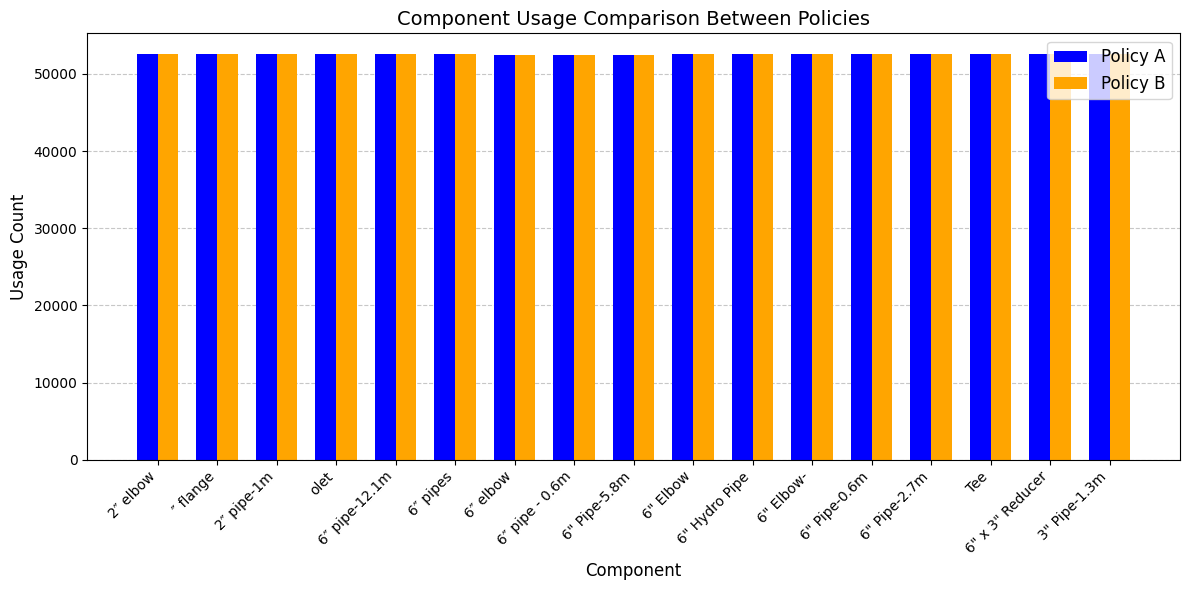

In [7]:

# Load the ANOVA results CSV file
anova_results = pd.read_csv("anova_components_results.csv")

# Create a bar plot for component usage comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(anova_results['Component']))

bar_width = 0.35
bars_a = ax.bar(x, anova_results['Usage_A'], width=bar_width, label='Policy A', color='blue')
bars_b = ax.bar([i + bar_width for i in x], anova_results['Usage_B'], width=bar_width, label='Policy B', color='orange')

# Add labels and title
ax.set_xlabel('Component', fontsize=12)
ax.set_ylabel('Usage Count', fontsize=12)
ax.set_title('Component Usage Comparison Between Policies', fontsize=14)
ax.set_xticks([i + bar_width / 2 for i in x])
ax.set_xticklabels(anova_results['Component'], rotation=45, ha='right', fontsize=10)

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Add legend
ax.legend(fontsize=12)

# Add values on top of the bars
def add_bar_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}', ha='center', va='bottom', fontsize=10)


# Adjust layout and save the plot
plt.tight_layout()
plt.show()

#### ANOVA Test for pipes production in Policies A and B 

In [8]:

# Lists of pipe production counts for each policy
pipes_a = list(pipes_count_a.values())
pipes_b = list(pipes_count_b.values())

# Hypotheses and confidence level
# Null Hypothesis (H0): The mean production counts of pipes are the same across Policy A and Policy B.
# Alternative Hypothesis (H1): There is a significant difference in the mean production counts of pipes between Policy A and Policy B.
# Confidence Level: 95% (alpha = 0.05)

# Perform ANOVA test
f_stat, p_value = stats.f_oneway(pipes_a, pipes_b)

# Print ANOVA test results
print("\nHypotheses:")
print("Null Hypothesis (H0):\nThe mean production counts of pipes are the same across Policy A and Policy B.")
print("Alternative Hypothesis (H1):\nThere is a significant difference in the mean production counts of pipes between Policy A and Policy B.")
print("Confidence Level: 95% (alpha = 0.05)")

print("\nANOVA Test Results:")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4e}")

# Conclusion
if p_value <= 0.05:
    print("\nDecision: Reject the null hypothesis (H0).")
    print("Conclusion: There is a significant difference in the mean production counts of pipes between Policy A and Policy B.")
else:
    print("\nDecision: Fail to reject the null hypothesis (H0).")
    print("Conclusion: There is no significant difference in the mean production counts of pipes between Policy A and Policy B.")

# Save results to CSV
anova_pipes_results = pd.DataFrame({
    'Pipe Type': list(pipes_count_a.keys()),
    'Production_Count_A': pipes_a,
    'Production_Count_B': pipes_b
})
anova_pipes_results.to_csv("anova_pipes_results.csv", index=False)

print("\nANOVA test results for pipes have been saved to 'anova_pipes_results.csv'")


Hypotheses:
Null Hypothesis (H0):
The mean production counts of pipes are the same across Policy A and Policy B.
Alternative Hypothesis (H1):
There is a significant difference in the mean production counts of pipes between Policy A and Policy B.
Confidence Level: 95% (alpha = 0.05)

ANOVA Test Results:
F-statistic: 0.4557
p-value: 5.3663e-01

Decision: Fail to reject the null hypothesis (H0).
Conclusion: There is no significant difference in the mean production counts of pipes between Policy A and Policy B.

ANOVA test results for pipes have been saved to 'anova_pipes_results.csv'


#### Bar Chart Visualization of Pipe Production Comparison Between Policies A and B

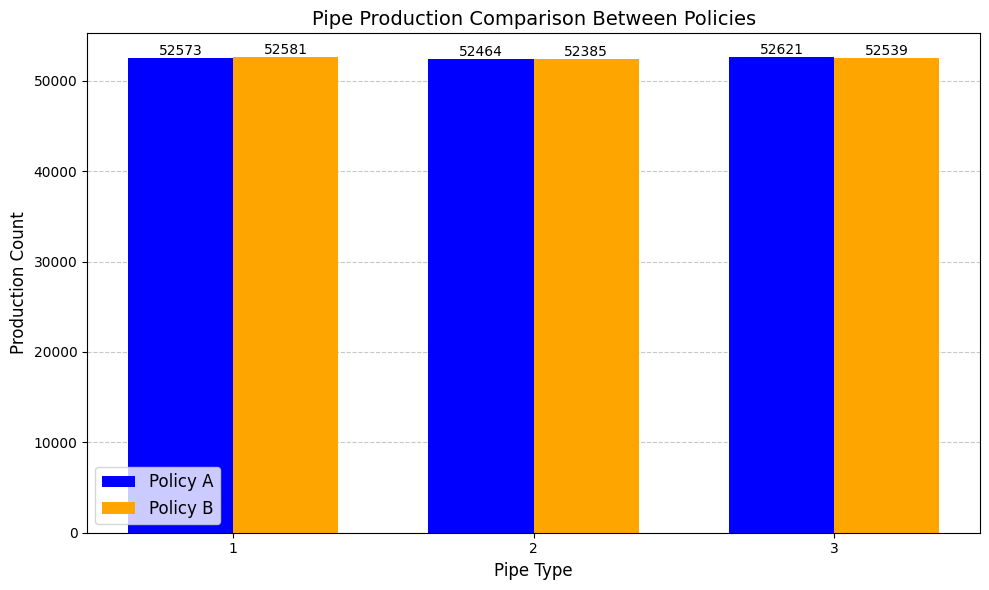

In [9]:

# Load the ANOVA results CSV file
anova_pipes_results = pd.read_csv("anova_pipes_results.csv")

# Create a bar plot for pipe production comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(anova_pipes_results['Pipe Type']))

bar_width = 0.35
bars_a = ax.bar(x, anova_pipes_results['Production_Count_A'], width=bar_width, label='Policy A', color='blue')
bars_b = ax.bar([i + bar_width for i in x], anova_pipes_results['Production_Count_B'], width=bar_width, label='Policy B', color='orange')

# Add labels and title
ax.set_xlabel('Pipe Type', fontsize=12)
ax.set_ylabel('Production Count', fontsize=12)
ax.set_title('Pipe Production Comparison Between Policies', fontsize=14)
ax.set_xticks([i + bar_width / 2 for i in x])
ax.set_xticklabels(anova_pipes_results['Pipe Type'], rotation=0, fontsize=10)

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Add legend
ax.legend(fontsize=12)

# Add values on top of the bars
def add_bar_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}', ha='center', va='bottom', fontsize=10)

add_bar_labels(bars_a)
add_bar_labels(bars_b)

# Adjust layout and save the plot
plt.tight_layout()
plt.show()

#### Analysis and Visualization of Average Production Time per Order for Policies A and B

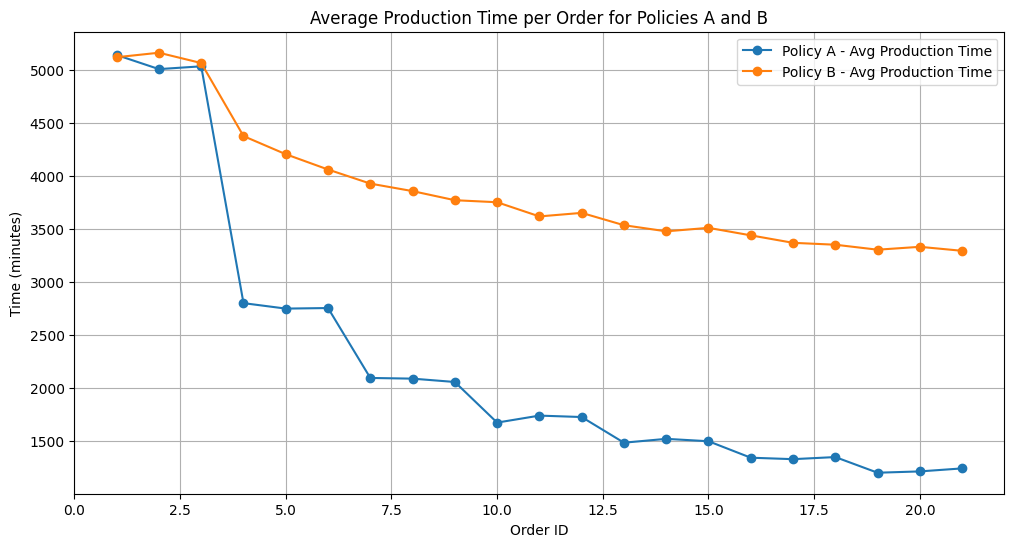

In [10]:
# Compute the averages of the key metrics for all simulations
average_production_time_a = policy_a_df.groupby("Order_ID")["Production_Time"].mean()
average_assembly_time_a = policy_a_df.groupby("Order_ID")["Assembly_Time"].mean()
average_total_time_a = policy_a_df.groupby("Order_ID")["Total_Time"].mean()

average_production_time_b = policy_b_df.groupby("Order_ID")["Production_Time"].mean()
average_assembly_time_b = policy_b_df.groupby("Order_ID")["Assembly_Time"].mean()
average_total_time_b = policy_b_df.groupby("Order_ID")["Total_Time"].mean()

# Plot the average Production Time for both policies
plt.figure(figsize=(12, 6))
plt.plot(average_production_time_a.index, average_production_time_a, label="Policy A - Avg Production Time", marker="o")
plt.plot(average_production_time_b.index, average_production_time_b, label="Policy B - Avg Production Time", marker="o")
plt.xlabel("Order ID")
plt.ylabel("Time (minutes)")
plt.title("Average Production Time per Order for Policies A and B")
plt.legend()
plt.grid()
plt.show()

#### Visualization of Average Assembly Time per Order for Policy A

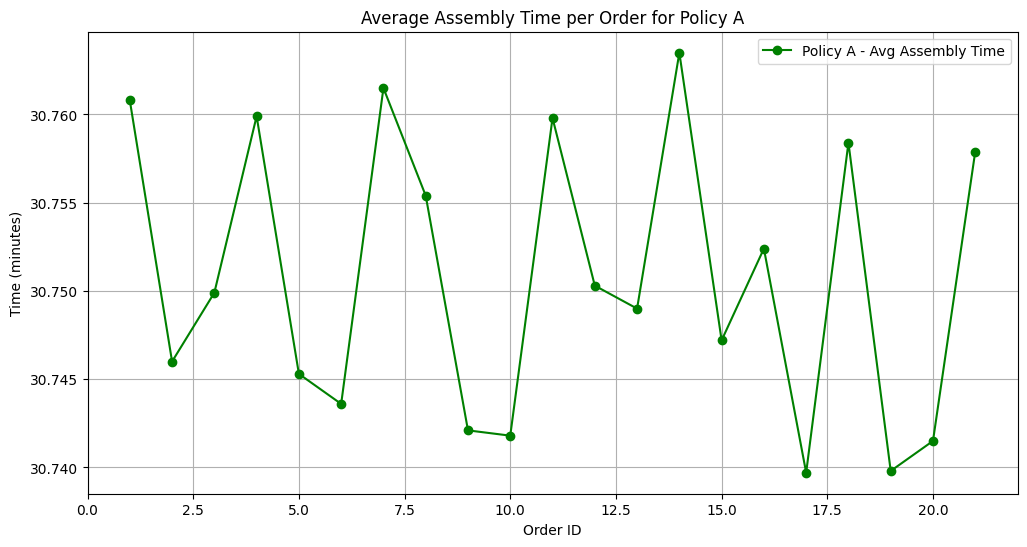

In [11]:
# Plot the average Assembly Time for Policy A
plt.figure(figsize=(12, 6))
plt.plot(average_assembly_time_a.index, average_assembly_time_a, label="Policy A - Avg Assembly Time", marker="o", color="green")
plt.xlabel("Order ID")
plt.ylabel("Time (minutes)")
plt.title("Average Assembly Time per Order for Policy A")
plt.legend()
plt.grid()
plt.show()

#### Visualization of Average Total Time per Order for Policies A and B

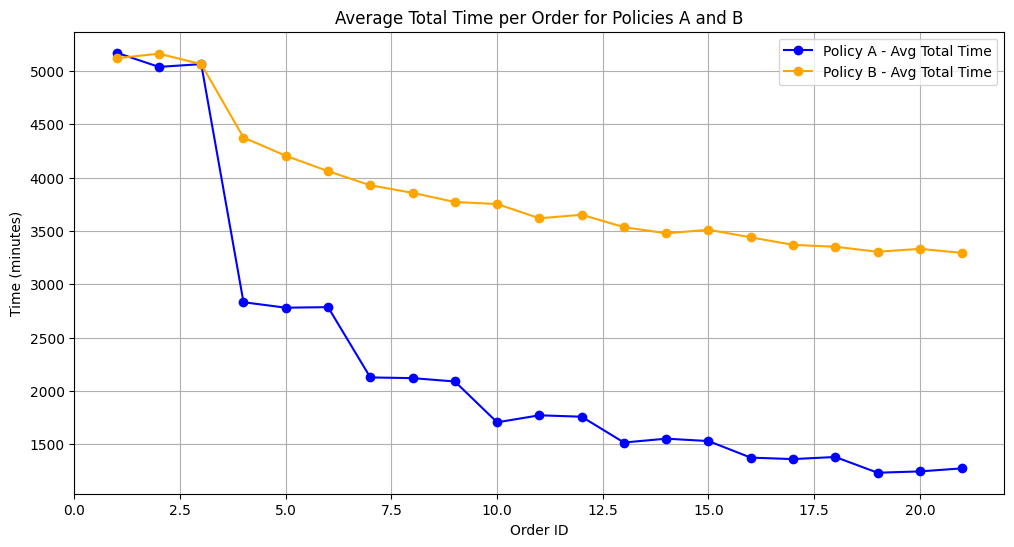

In [12]:
# Plot the average Total Time for both policies
plt.figure(figsize=(12, 6))
plt.plot(average_total_time_a.index, average_total_time_a, label="Policy A - Avg Total Time", marker="o", color="blue")
plt.plot(average_total_time_b.index, average_total_time_b, label="Policy B - Avg Total Time", marker="o", color="orange")
plt.xlabel("Order ID")
plt.ylabel("Time (minutes)")
plt.title("Average Total Time per Order for Policies A and B")
plt.legend()
plt.grid()
plt.show()

#### Comparison and Statistical Analysis of Total Time for Policies A and B

Average Total Time Comparison:
Policy A: 2271.63 minutes
Policy B: 3866.42 minutes


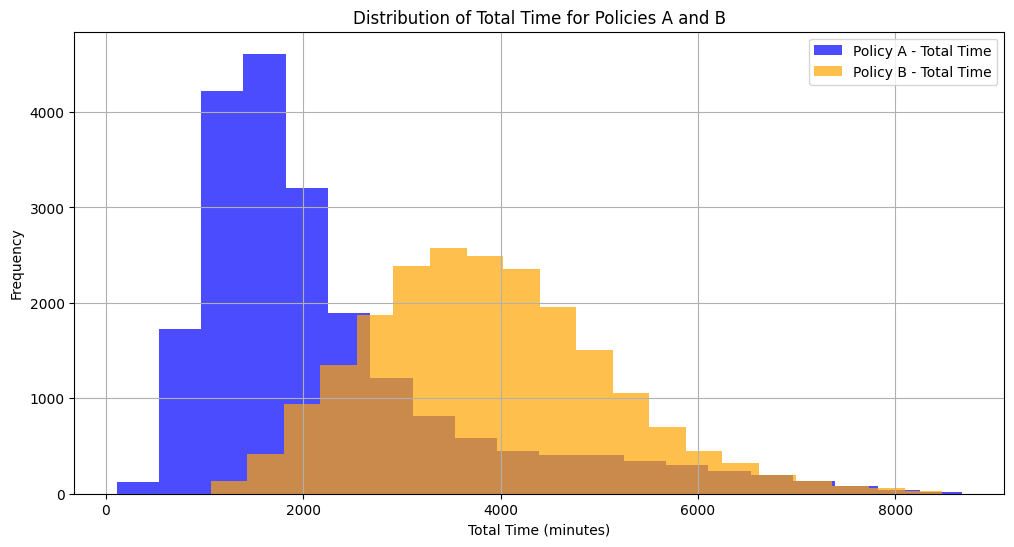

C:\Users\nirch\AppData\Local\Temp\ipykernel_23512\1990037310.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([policy_a_df["Total_Time"], policy_b_df["Total_Time"]], labels=["Policy A", "Policy B"])


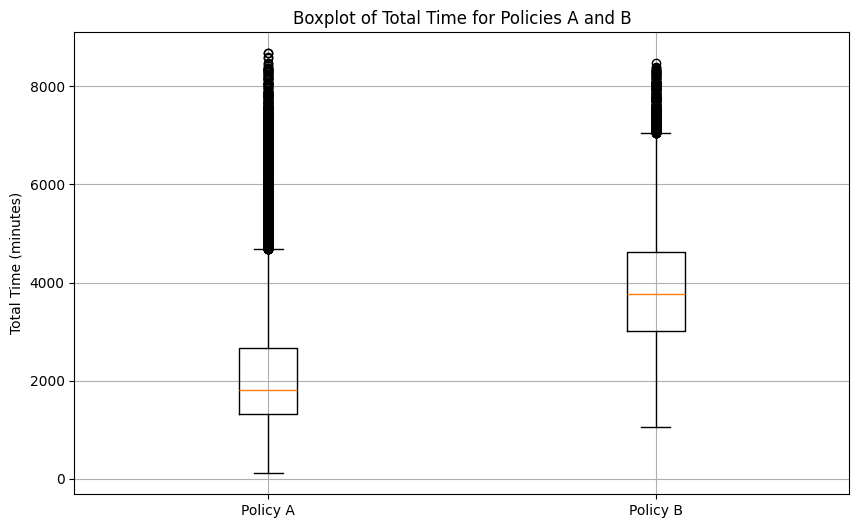


Descriptive Statistics for Total Time:

Policy A:
count    21000.000000
mean      2271.626331
std       1446.464824
min        110.920237
25%       1325.444876
50%       1804.847655
75%       2668.770333
max       8675.349203
Name: Total_Time, dtype: float64

Policy B:
count    21000.000000
mean      3866.424264
std       1212.727021
min       1062.957737
25%       3006.164589
50%       3771.647111
75%       4620.813288
max       8469.513185
Name: Total_Time, dtype: float64


In [13]:
# Compare average total time for both policies
avg_total_time_a = policy_a_df["Total_Time"].mean()
avg_total_time_b = policy_b_df["Total_Time"].mean()

print("Average Total Time Comparison:")
print(f"Policy A: {avg_total_time_a:.2f} minutes")
print(f"Policy B: {avg_total_time_b:.2f} minutes")

# Plot histogram for Total Time distribution
plt.figure(figsize=(12, 6))
plt.hist(policy_a_df["Total_Time"], bins=20, alpha=0.7, label="Policy A - Total Time", color="blue")
plt.hist(policy_b_df["Total_Time"], bins=20, alpha=0.7, label="Policy B - Total Time", color="orange")
plt.xlabel("Total Time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Time for Policies A and B")
plt.legend()
plt.grid()
plt.show()

# Boxplot for Total Time comparison
plt.figure(figsize=(10, 6))
plt.boxplot([policy_a_df["Total_Time"], policy_b_df["Total_Time"]], labels=["Policy A", "Policy B"])
plt.ylabel("Total Time (minutes)")
plt.title("Boxplot of Total Time for Policies A and B")
plt.grid()
plt.show()

# Display descriptive statistics for Total Time
print("\nDescriptive Statistics for Total Time:")
print("\nPolicy A:")
print(policy_a_df["Total_Time"].describe())
print("\nPolicy B:")
print(policy_b_df["Total_Time"].describe())

#### Saving Summary Results of 1000 Simulations for Policies A and B

In [14]:
# Convert all_results_a and all_results_b to DataFrames for further analysis or saving
import pandas as pd

summary_df_a = pd.DataFrame(all_results_a)
summary_df_b = pd.DataFrame(all_results_b)

# Save summary results to CSV
summary_df_a.to_csv("policy_a_summary_1000_simulations.csv", index=False)
summary_df_b.to_csv("policy_b_summary_1000_simulations.csv", index=False)

print("Simulations completed and results saved.")

Simulations completed and results saved.


#### Scatter Plot of Production Time vs. Waiting Time for Policies A and B

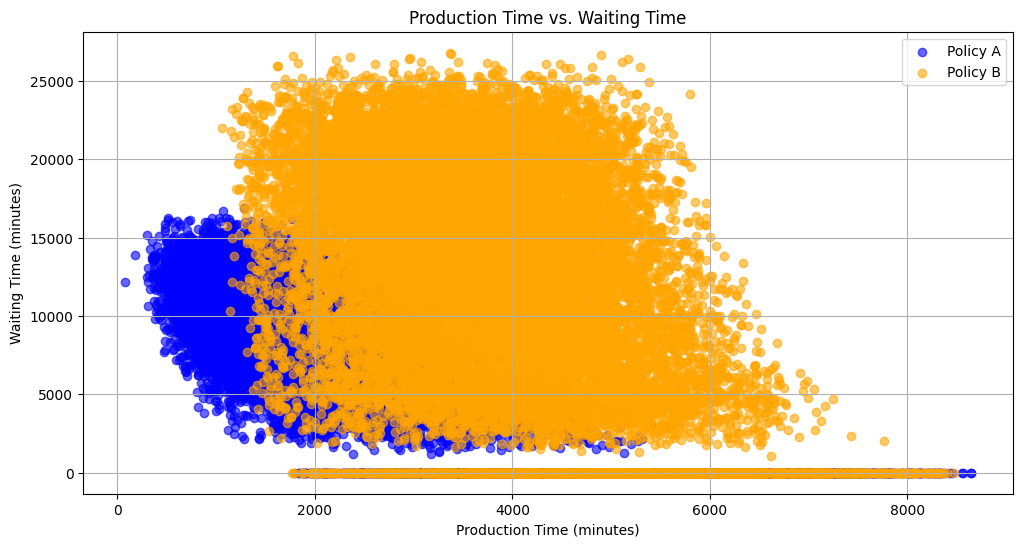

In [15]:
plt.figure(figsize=(12, 6))
plt.scatter(policy_a_df["Production_Time"], policy_a_df["Waiting_Time"], alpha=0.6, label="Policy A", color="blue")
plt.scatter(policy_b_df["Production_Time"], policy_b_df["Waiting_Time"], alpha=0.6, label="Policy B", color="orange")
plt.xlabel("Production Time (minutes)")
plt.ylabel("Waiting Time (minutes)")
plt.title("Production Time vs. Waiting Time")
plt.legend()
plt.grid()
plt.show()

#### Correlation Analysis of Key Metrics for Policies A and B

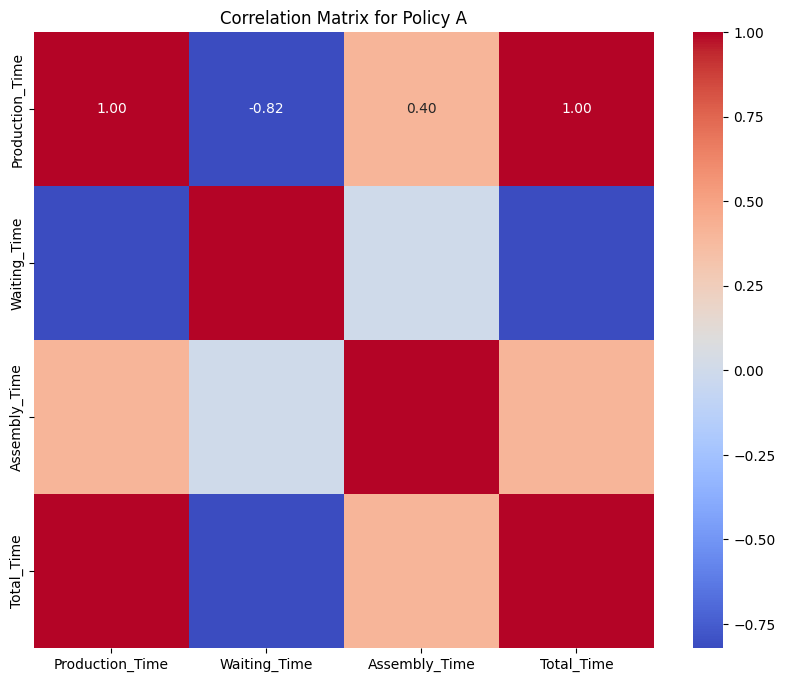

C:\Users\nirch\anaconda3\envs\data_analysis\lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


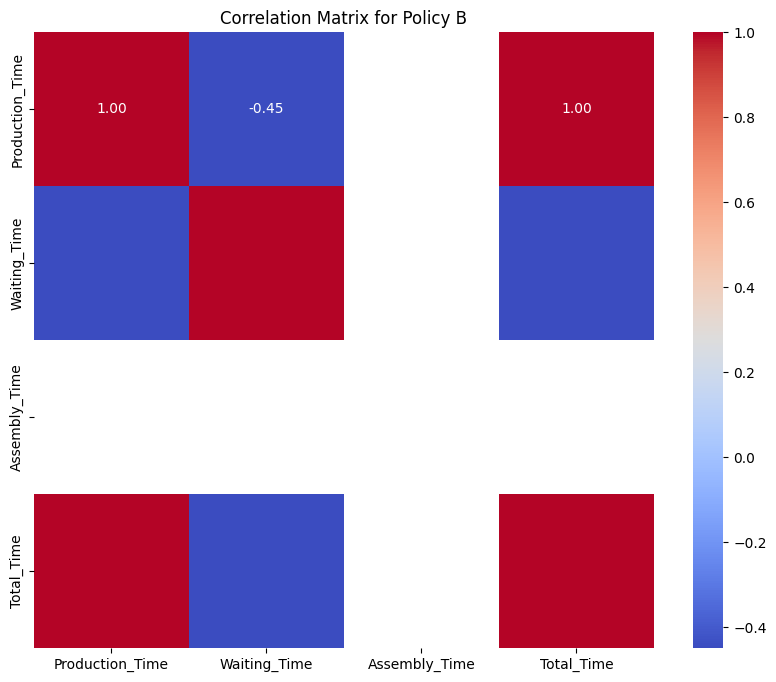

The assembly time in policy B is always 0


In [16]:
import seaborn as sns

policy_a_corr = policy_a_df[["Production_Time", "Waiting_Time", "Assembly_Time", "Total_Time"]].corr()
policy_b_corr = policy_b_df[["Production_Time", "Waiting_Time", "Assembly_Time", "Total_Time"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(policy_a_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Policy A")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(policy_b_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Policy B")
plt.show()
print("The assembly time in policy B is always 0")

#### Pie Chart Comparison of Spool Proportion for Policies A and B

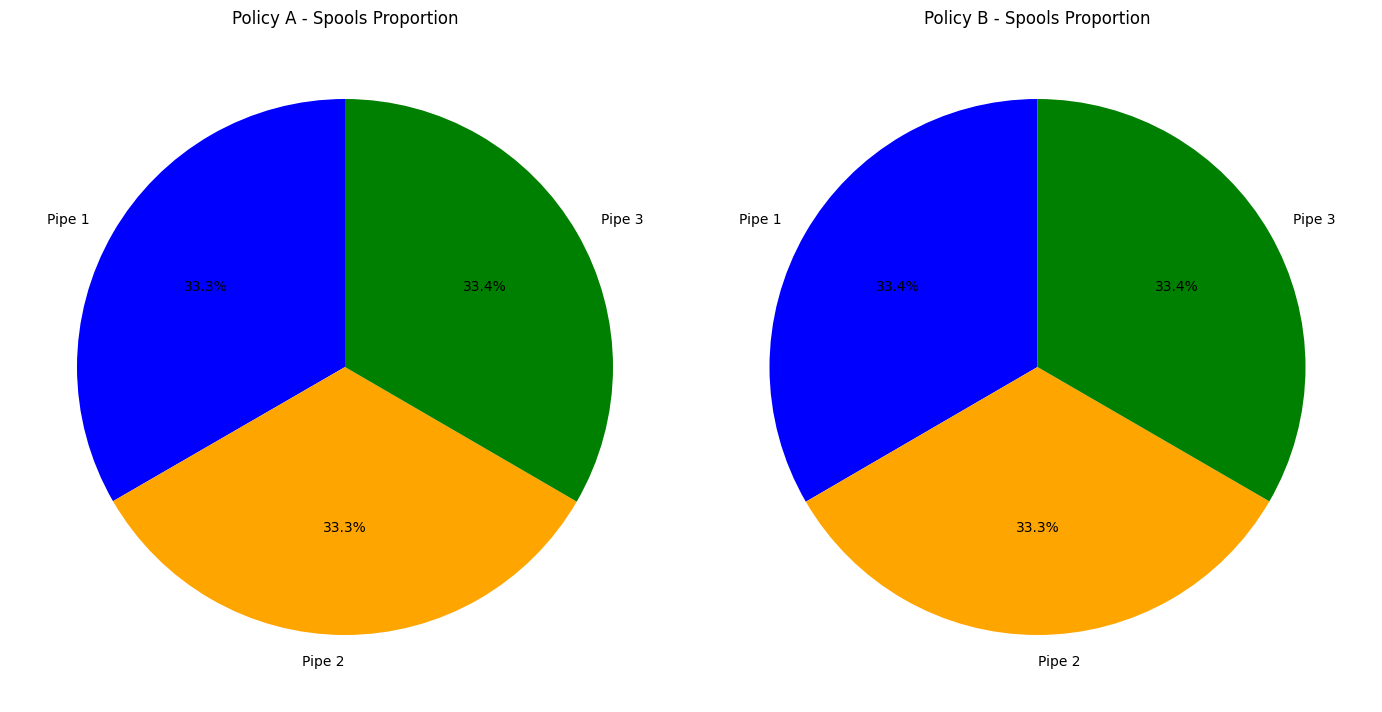

In [17]:
spool_labels = [f"Pipe {key}" for key in pipes_count_a.keys()]
spools_a = list(pipes_count_a.values())
spools_b = list(pipes_count_b.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].pie(spools_a, labels=spool_labels, autopct='%1.1f%%', startangle=90, colors=["blue", "orange", "green"])
axes[0].set_title("Policy A - Spools Proportion")

axes[1].pie(spools_b, labels=spool_labels, autopct='%1.1f%%', startangle=90, colors=["blue", "orange", "green"])
axes[1].set_title("Policy B - Spools Proportion")

plt.tight_layout()
plt.show()

#### Bar Chart Comparison of Average Production, Assembly, and Total Time for Policies A and B

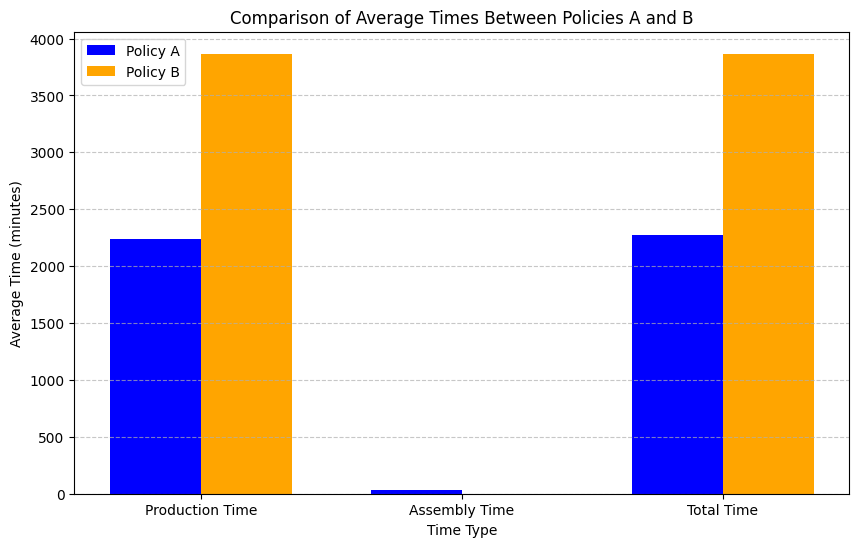

In [18]:

# Calculate overall averages for production, assembly, and total time
avg_times_a = [
    policy_a_df["Production_Time"].mean(),
    policy_a_df["Assembly_Time"].mean(),
    policy_a_df["Total_Time"].mean(),
]
avg_times_b = [
    policy_b_df["Production_Time"].mean(),
    policy_b_df["Assembly_Time"].mean(),
    policy_b_df["Total_Time"].mean(),
]

labels = ["Production Time", "Assembly Time", "Total Time"]
x = range(len(labels))

# Plot the bar chart
plt.figure(figsize=(10, 6))
bar_width = 0.35
plt.bar(x, avg_times_a, width=bar_width, label="Policy A", color="blue")
plt.bar([i + bar_width for i in x], avg_times_b, width=bar_width, label="Policy B", color="orange")
plt.xlabel("Time Type")
plt.ylabel("Average Time (minutes)")
plt.title("Comparison of Average Times Between Policies A and B")
plt.xticks([i + bar_width / 2 for i in x], labels)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

#### Pie Chart Comparison of Total Waiting Times for Policies A and B

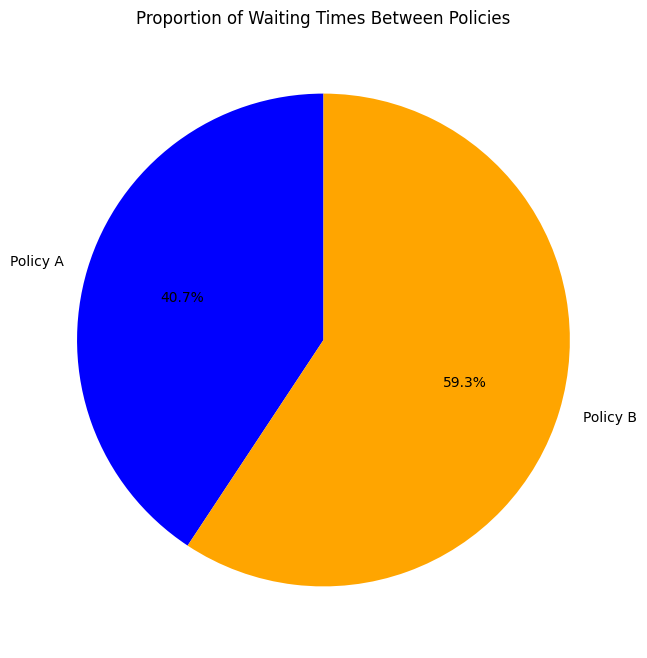

In [19]:
waiting_times_a = policy_a_df["Waiting_Time"].sum()
waiting_times_b = policy_b_df["Waiting_Time"].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    [waiting_times_a, waiting_times_b],
    labels=["Policy A", "Policy B"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["blue", "orange"],
)
plt.title("Proportion of Waiting Times Between Policies")
plt.show()

#### Histogram of Waiting Time Distribution for Policies A and B

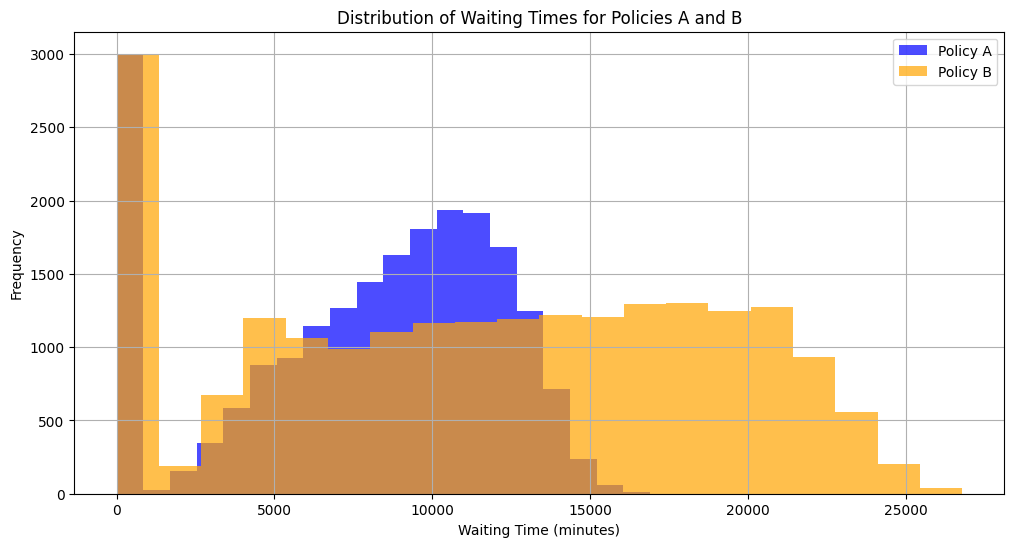

In [20]:
plt.figure(figsize=(12, 6))
plt.hist(policy_a_df["Waiting_Time"], bins=20, alpha=0.7, label="Policy A", color="blue")
plt.hist(policy_b_df["Waiting_Time"], bins=20, alpha=0.7, label="Policy B", color="orange")
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Waiting Times for Policies A and B")
plt.legend()
plt.grid()
plt.show()

#### Boxplot of Production Time by Pipe Type for Policies A and B

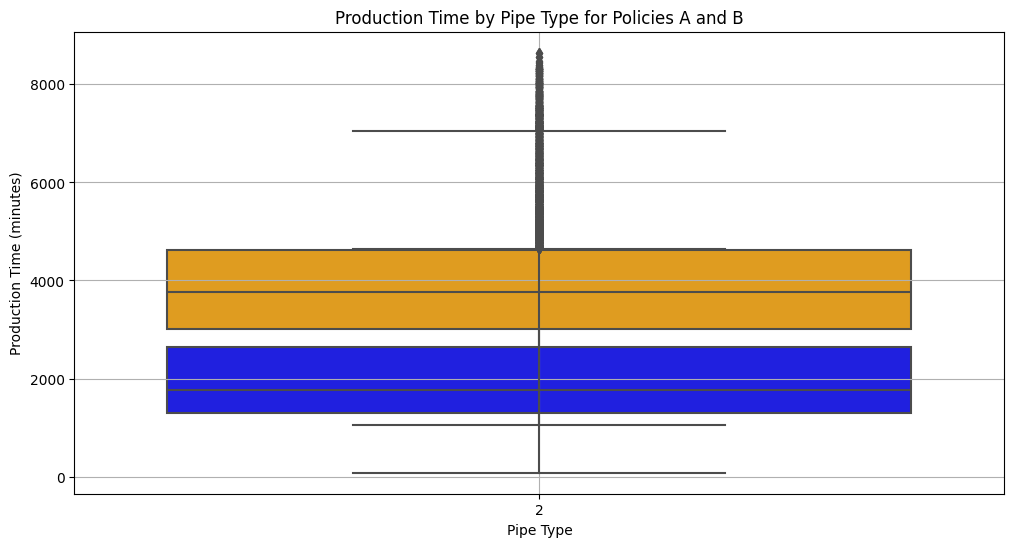

In [21]:
# Extract pipe types and production times for each policy
pipe_types_a = policy_a_df["Pipe_Quantities"].apply(lambda x: list(x.keys())[0])
pipe_types_b = policy_b_df["Pipe_Quantities"].apply(lambda x: list(x.keys())[0])

plt.figure(figsize=(12, 6))
sns.boxplot(x=pipe_types_a, y=policy_a_df["Production_Time"], color="blue")
sns.boxplot(x=pipe_types_b, y=policy_b_df["Production_Time"], color="orange")
plt.xlabel("Pipe Type")
plt.ylabel("Production Time (minutes)")
plt.title("Production Time by Pipe Type for Policies A and B")
plt.grid()
plt.show()